In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix


In [56]:
df = pd.read_csv(r"C:\Users\praka\Tanvi Project\projectdataset.csv")
df.head(10)

,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,...,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,INJURIES_NO_INDICATION.1,INJURIES_UNKNOWN.1,CRASH_HOUR.1,CRASH_DAY_OF_WEEK.1,CRASH_MONTH.1
0,SNOW,DAYLIGHT,SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,SNOW OR SLUSH,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,...,2.0,0.0,12,3,1,2.0,0.0,12.0,3.0,1.0
1,UNKNOWN,DAYLIGHT,TURNING,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,...,2.0,0.0,9,6,5,2.0,0.0,9.0,6.0,5.0
2,CLEAR,UNKNOWN,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,...,1.0,0.0,20,7,4,1.0,0.0,20.0,7.0,4.0
3,CLEAR,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,...,2.0,0.0,9,6,5,2.0,0.0,9.0,6.0,5.0
4,SNOW,DAYLIGHT,REAR END,FOUR WAY,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,...,2.0,0.0,8,3,1,2.0,0.0,8.0,3.0,1.0
5,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,...,1.0,0.0,13,3,1,1.0,0.0,13.0,3.0,1.0
6,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,...,2.0,0.0,23,1,3,2.0,0.0,23.0,1.0,3.0
7,UNKNOWN,UNKNOWN,TURNING,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,...,2.0,0.0,8,4,12,2.0,0.0,8.0,4.0,12.0
8,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE OPPOSITE DIRECTION,NOT DIVIDED,NaN,STRAIGHT ON GRADE,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,...,3.0,0.0,3,7,10,3.0,0.0,3.0,7.0,10.0
9,CLEAR,DARKNESS,FIXED OBJECT,DIVIDED - W/MEDIAN BARRIER,NaN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,...,1.0,0.0,22,7,9,1.0,0.0,22.0,7.0,9.0


In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   WEATHER_CONDITION              9999 non-null   object 
 1   LIGHTING_CONDITION             9999 non-null   object 
 2   FIRST_CRASH_TYPE               9999 non-null   object 
 3   TRAFFICWAY_TYPE                9999 non-null   object 
 4   LANE_CNT                       4 non-null      float64
 5   ALIGNMENT                      9999 non-null   object 
 6   ROADWAY_SURFACE_COND           9999 non-null   object 
 7   ROAD_DEFECT                    9999 non-null   object 
 8   REPORT_TYPE                    9455 non-null   object 
 9   CRASH_TYPE                     9999 non-null   object 
 10  INTERSECTION_RELATED_I         2365 non-null   object 
 11  NOT_RIGHT_OF_WAY_I             429 non-null    object 
 12  HIT_AND_RUN_I                  3085 non-null   o

In [58]:
print(df.describe())

       LANE_CNT     STREET_NO  BEAT_OF_OCCURRENCE    NUM_UNITS  \
count       4.0   9999.000000         9999.000000  9999.000000   
mean        2.0   3653.392039         1273.744274     2.032703   
std         0.0   2826.314141          703.963190     0.421267   
min         2.0      0.000000          111.000000     1.000000   
25%         2.0   1254.000000          734.000000     2.000000   
50%         2.0   3153.000000         1222.000000     2.000000   
75%         2.0   5500.000000         1824.000000     2.000000   
max         2.0  13799.000000         6100.000000    10.000000   

       INJURIES_TOTAL  INJURIES_FATAL  INJURIES_INCAPACITATING  \
count     9982.000000     9982.000000              9982.000000   
mean         0.222501        0.001102                 0.016830   
std          0.609745        0.033180                 0.158635   
min          0.000000        0.000000                 0.000000   
25%          0.000000        0.000000                 0.000000   
50%      

In [59]:

df = df.drop(columns=[c for c in df.columns if '.1' in c])
cols_to_drop = ['LANE_CNT', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NOT_RIGHT_OF_WAY_I', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'INTERSECTION_RELATED_I', 'HIT_AND_RUN_I']
df = df.drop(columns=cols_to_drop, errors='ignore')
df['MOST_SEVERE_INJURY'] = df['MOST_SEVERE_INJURY'].fillna('NO INDICATION OF INJURY')
df['INJURIES_TOTAL'] = df['INJURIES_TOTAL'].fillna(0)
df['HAS_INJURY'] = (df['INJURIES_TOTAL'] > 0).astype(int)
damage_map = {'$500 OR LESS': 0, '$501 - $1,500': 1, 'OVER $1,500': 2}
df['DAMAGE_ORD'] = df['DAMAGE'].map(damage_map)


In [79]:

le = LabelEncoder()
cat_cols = ['WEATHER_CONDITION', 'LIGHTING_CONDITION', 'ROADWAY_SURFACE_COND', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE']
for col in cat_cols:
    df[col + '_ENC'] = le.fit_transform(df[col])
features = [c + '_ENC' for c in cat_cols] + ['CRASH_HOUR', 'CRASH_DAY_OF_WEEK']
X = df[features]
y_reg = df['INJURIES_TOTAL']
y_clf = df['HAS_INJURY']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(X_scaled, y_reg, y_clf, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_reg_train)
y_reg_pred = lr.predict(X_test)
mse = mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"Regression MSE: {mse}")
print(f"Regression R2: {r2}")


Regression MSE: 0.376438715217192
Regression R2: 0.013331171359513005



1. Multiple Linear Regression Results:
   Mean Absolute Error (MAE): 0.3694
   Mean Squared Error (MSE): 0.3764
   Root Mean Squared Error (RMSE): 0.6135
   R-squared (R²) Score: 0.0133

2. Polynomial Regression (Degree 2) Results:
   Mean Absolute Error (MAE): 0.3641
   Mean Squared Error (MSE): 0.3721
   Root Mean Squared Error (RMSE): 0.6100
   R-squared (R²) Score: 0.0248

3. Logistic Regression for Binary Classification:
   Accuracy: 0.8373


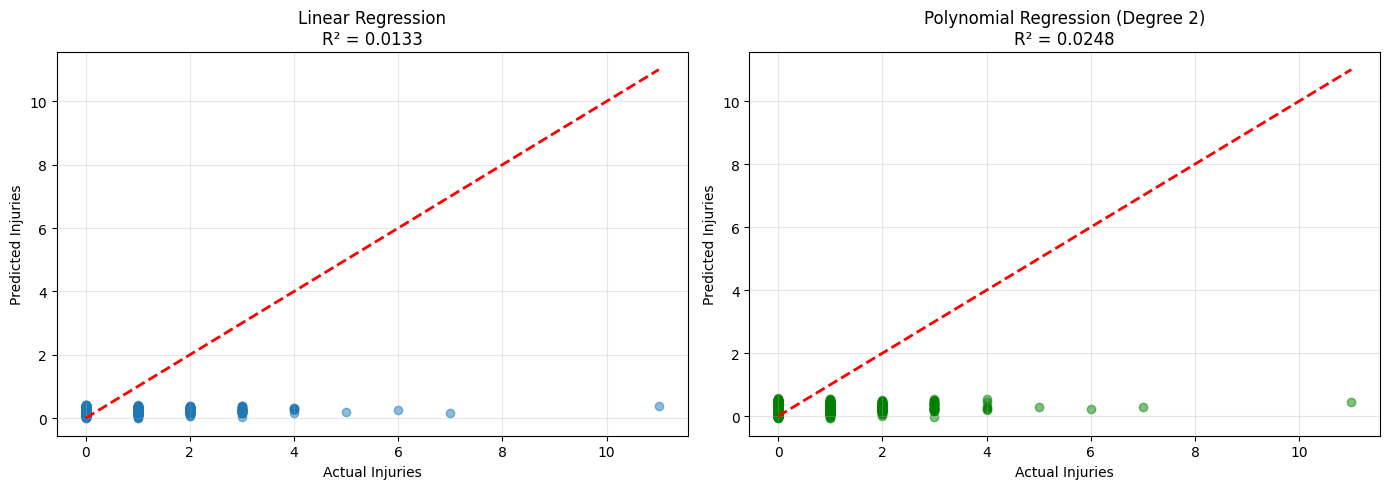

In [81]:

y_reg_pred = lr.predict(X_test)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("\n1. Multiple Linear Regression Results:")
print(f"   Mean Absolute Error (MAE): {mae:.4f}")
print(f"   Mean Squared Error (MSE): {mse:.4f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   R-squared (R²) Score: {r2:.4f}")

# 3. Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_reg_train)
y_poly_pred = poly_reg.predict(X_test_poly)

mae_poly = mean_absolute_error(y_reg_test, y_poly_pred)
mse_poly = mean_squared_error(y_reg_test, y_poly_pred)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_reg_test, y_poly_pred)

print("\n2. Polynomial Regression (Degree 2) Results:")
print(f"   Mean Absolute Error (MAE): {mae_poly:.4f}")
print(f"   Mean Squared Error (MSE): {mse_poly:.4f}")
print(f"   Root Mean Squared Error (RMSE): {rmse_poly:.4f}")
print(f"   R-squared (R²) Score: {r2_poly:.4f}")

# 4. Logistic Regression for Binary Classification (HAS_INJURY)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_clf_train)
y_log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_clf_test, y_log_pred)

print("\n3. Logistic Regression for Binary Classification:")
print(f"   Accuracy: {log_acc:.4f}")

# Visualize Regression Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Linear Regression Predictions vs Actual
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.5)
axes[0].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Injuries')
axes[0].set_ylabel('Predicted Injuries')
axes[0].set_title(f'Linear Regression\nR² = {r2:.4f}')
axes[0].grid(True, alpha=0.3)

# Plot 2: Polynomial Regression Predictions vs Actual
axes[1].scatter(y_reg_test, y_poly_pred, alpha=0.5, color='green')
axes[1].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Injuries')
axes[1].set_ylabel('Predicted Injuries')
axes[1].set_title(f'Polynomial Regression (Degree 2)\nR² = {r2_poly:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


1. Cross-Validation Methods:
------------------------------------------------------------

a) K-Fold Cross-Validation (K=5):

   Logistic Regression:
   CV Scores: [0.8375     0.841      0.85       0.8495     0.82791396]
   Mean Accuracy: 0.8412 (+/- 0.0082)

   Decision Tree:
   CV Scores: [0.804      0.815      0.823      0.8105     0.80090045]
   Mean Accuracy: 0.8107 (+/- 0.0079)

   Random Forest:
   CV Scores: [0.838      0.853      0.8445     0.846      0.83041521]
   Mean Accuracy: 0.8424 (+/- 0.0077)

   Random Forest:
   CV Scores: [0.838      0.853      0.8445     0.846      0.83041521]
   Mean Accuracy: 0.8424 (+/- 0.0077)

   KNN:
   CV Scores: [0.8185    0.822     0.833     0.824     0.8164082]
   Mean Accuracy: 0.8228 (+/- 0.0058)

   KNN:
   CV Scores: [0.8185    0.822     0.833     0.824     0.8164082]
   Mean Accuracy: 0.8228 (+/- 0.0058)

   SVM:
   CV Scores: [0.8375     0.841      0.85       0.8495     0.82791396]
   Mean Accuracy: 0.8412 (+/- 0.0082)

   SVM:
   

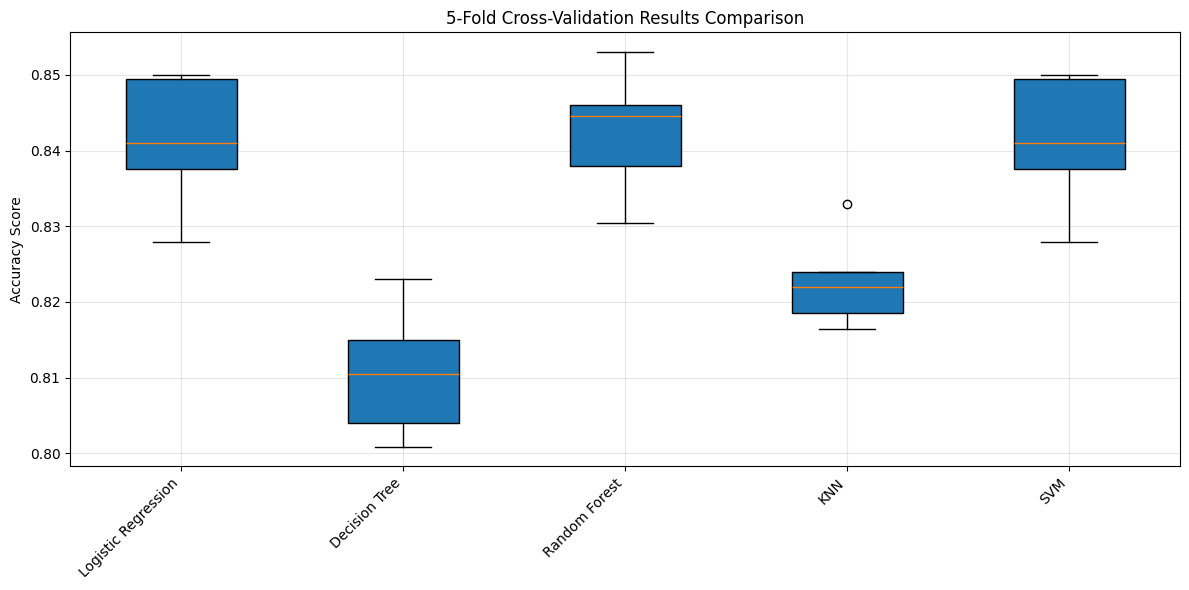


b) Cross-Validation with Different K Values (using Random Forest):
   K=3: Mean Accuracy = 0.8402 (+/- 0.0039)
   K=3: Mean Accuracy = 0.8402 (+/- 0.0039)
   K=5: Mean Accuracy = 0.8424 (+/- 0.0077)
   K=5: Mean Accuracy = 0.8424 (+/- 0.0077)
   K=10: Mean Accuracy = 0.8421 (+/- 0.0114)

c) Leave-One-Out (LOO) Cross-Validation (on 500 samples):
   K=10: Mean Accuracy = 0.8421 (+/- 0.0114)

c) Leave-One-Out (LOO) Cross-Validation (on 500 samples):
   LOO Accuracy: 0.8420 (+/- 0.3647)
   Number of iterations: 500
   LOO Accuracy: 0.8420 (+/- 0.3647)
   Number of iterations: 500


In [62]:

print("\n1. Cross-Validation Methods:")
print("-" * 60)

# K-Fold Cross-Validation
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut

# Test different models with K-Fold Cross-Validation
models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42)
}

print("\na) K-Fold Cross-Validation (K=5):")
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models_cv.items():
    cv_scores = cross_val_score(model, X_scaled, y_clf, cv=kfold, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"\n   {name}:")
    print(f"   CV Scores: {cv_scores}")
    print(f"   Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Visualize CV Results
plt.figure(figsize=(12, 6))
plt.boxplot([cv_results[name] for name in cv_results.keys()], 
            tick_labels=cv_results.keys(), patch_artist=True)
plt.ylabel('Accuracy Score')
plt.title('5-Fold Cross-Validation Results Comparison')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# K-Fold with different K values
print("\nb) Cross-Validation with Different K Values (using Random Forest):")
k_values = [3, 5, 10]
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

for k in k_values:
    kfold_temp = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(rf_model, X_scaled, y_clf, cv=kfold_temp, scoring='accuracy')
    print(f"   K={k}: Mean Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Leave-One-Out Cross-Validation (on a sample due to computational cost)
print("\nc) Leave-One-Out (LOO) Cross-Validation (on 500 samples):")
sample_size = 500
sample_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample_loo = X_scaled[sample_idx]
y_sample_loo = y_clf.iloc[sample_idx]

loo = LeaveOneOut()
loo_model = LogisticRegression(max_iter=1000, random_state=42)
loo_scores = cross_val_score(loo_model, X_sample_loo, y_sample_loo, cv=loo, scoring='accuracy')
print(f"   LOO Accuracy: {loo_scores.mean():.4f} (+/- {loo_scores.std():.4f})")
print(f"   Number of iterations: {loo.get_n_splits(X_sample_loo)}")


2. Bias-Variance Trade-off:
------------------------------------------------------------

   Decision Tree Complexity Analysis (max_depth):
   Depth=1               | Train Acc: 0.8428 | Test Acc: 0.8373
   Depth=2               | Train Acc: 0.8428 | Test Acc: 0.8373
   Depth=5               | Train Acc: 0.8740 | Test Acc: 0.8667
   Depth=10              | Train Acc: 0.8931 | Test Acc: 0.8570
   Depth=20              | Train Acc: 0.9501 | Test Acc: 0.8180
   Depth=None (unlimited) | Train Acc: 0.9600 | Test Acc: 0.8077


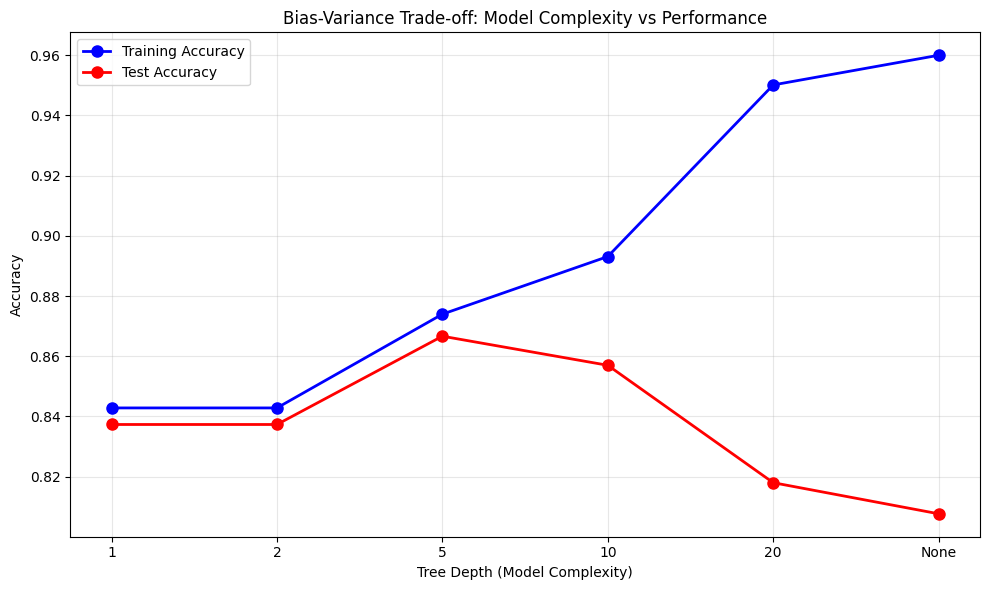


   Analysis:
   - Low depth (high bias): Underfitting - poor performance on both train and test
   - Moderate depth: Good balance - similar train and test performance
   - High depth (high variance): Overfitting - great train performance, worse test performance


In [53]:

print("\n2. Bias-Variance Trade-off:")
print("-" * 60)

# Compare models with different complexity levels
from sklearn.tree import DecisionTreeClassifier

# Train Decision Trees with different max_depth (complexity)
depths = [1, 2, 5, 10, 20, None]
train_scores = []
test_scores = []

print("\n   Decision Tree Complexity Analysis (max_depth):")
for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_clf_train)
    
    train_score = dt_temp.score(X_train, y_clf_train)
    test_score = dt_temp.score(X_test, y_clf_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    depth_str = str(depth) if depth is not None else "None (unlimited)"
    print(f"   Depth={depth_str:15} | Train Acc: {train_score:.4f} | Test Acc: {test_score:.4f}")

# Visualize Bias-Variance Trade-off
plt.figure(figsize=(10, 6))
x_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = np.arange(len(depths))

plt.plot(x_pos, train_scores, 'bo-', linewidth=2, markersize=8, label='Training Accuracy')
plt.plot(x_pos, test_scores, 'ro-', linewidth=2, markersize=8, label='Test Accuracy')
plt.xticks(x_pos, x_labels)
plt.xlabel('Tree Depth (Model Complexity)')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Trade-off: Model Complexity vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bias_variance_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n   Analysis:")
print("   - Low depth (high bias): Underfitting - poor performance on both train and test")
print("   - Moderate depth: Good balance - similar train and test performance")
print("   - High depth (high variance): Overfitting - great train performance, worse test performance")

In [63]:
# 3. Bagging (Bootstrap Aggregating)
print("\n3. Bagging (Bootstrap Aggregating):")
print("-" * 60)

from sklearn.ensemble import BaggingClassifier

# Create Bagging classifier with Decision Tree as base estimator
bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42
)

bagging_dt.fit(X_train, y_clf_train)
bagging_pred = bagging_dt.predict(X_test)
bagging_acc = accuracy_score(y_clf_test, bagging_pred)

print("\n   Bagging with Decision Trees:")
print(f"   Number of estimators: 50")
print(f"   Accuracy: {bagging_acc:.4f}")
print(f"\n   Classification Report:")
print(classification_report(y_clf_test, bagging_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

# Compare single Decision Tree vs Bagging
single_dt = DecisionTreeClassifier(random_state=42)
single_dt.fit(X_train, y_clf_train)
single_dt_acc = single_dt.score(X_test, y_clf_test)

print(f"\n   Comparison:")
print(f"   Single Decision Tree: {single_dt_acc:.4f}")
print(f"   Bagging (50 trees):   {bagging_acc:.4f}")
print(f"   Improvement: {(bagging_acc - single_dt_acc):.4f}")


3. Bagging (Bootstrap Aggregating):
------------------------------------------------------------

   Bagging with Decision Trees:
   Number of estimators: 50
   Accuracy: 0.8630

   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.87      0.98      0.92      2512
  Has Injury       0.75      0.24      0.36       488

    accuracy                           0.86      3000
   macro avg       0.81      0.61      0.64      3000
weighted avg       0.85      0.86      0.83      3000


   Comparison:
   Single Decision Tree: 0.8077
   Bagging (50 trees):   0.8630
   Improvement: 0.0553

   Bagging with Decision Trees:
   Number of estimators: 50
   Accuracy: 0.8630

   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.87      0.98      0.92      2512
  Has Injury       0.75      0.24      0.36       488

    accuracy                           0.86      3000
   macro avg       0.81      0.61     


4. Random Forests:
------------------------------------------------------------

   Random Forest with Different Number of Trees:
   Trees= 10: Accuracy = 0.8437
   Trees= 50: Accuracy = 0.8447
   Trees= 50: Accuracy = 0.8447
   Trees=100: Accuracy = 0.8470
   Trees=100: Accuracy = 0.8470
   Trees=200: Accuracy = 0.8483
   Trees=200: Accuracy = 0.8483

   Best Random Forest (100 trees):
   Accuracy: 0.8470

   Feature Importance:
   1. FIRST_CRASH_TYPE_ENC           0.2894
   2. CRASH_HOUR                     0.2680
   3. CRASH_DAY_OF_WEEK              0.1568
   4. TRAFFICWAY_TYPE_ENC            0.1448
   5. LIGHTING_CONDITION_ENC         0.0510
   6. WEATHER_CONDITION_ENC          0.0493
   7. ROADWAY_SURFACE_COND_ENC       0.0408

   Best Random Forest (100 trees):
   Accuracy: 0.8470

   Feature Importance:
   1. FIRST_CRASH_TYPE_ENC           0.2894
   2. CRASH_HOUR                     0.2680
   3. CRASH_DAY_OF_WEEK              0.1568
   4. TRAFFICWAY_TYPE_ENC            0.1448
 

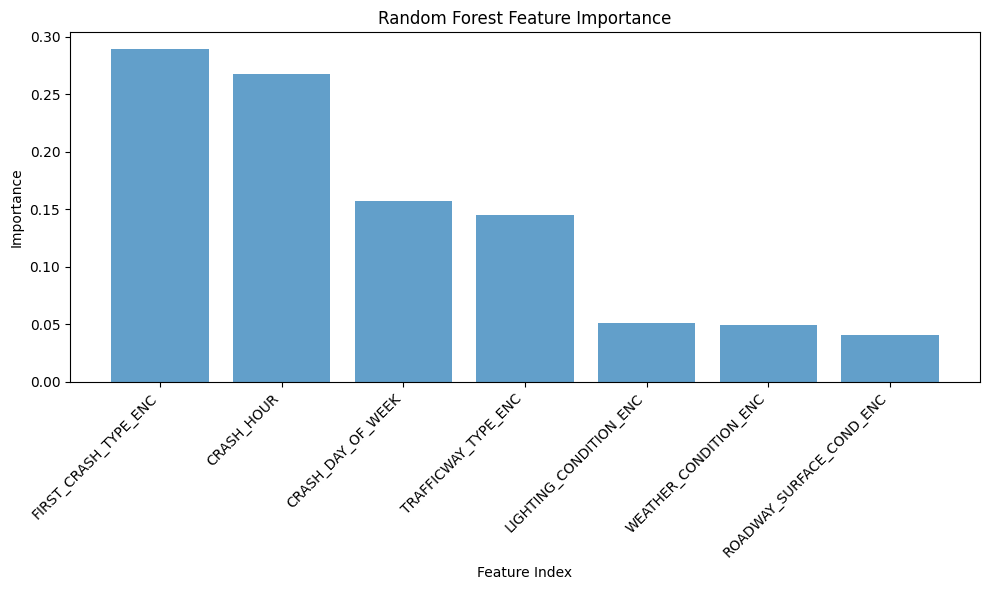

In [64]:
# 4. Random Forests (Special case of Bagging)
print("\n4. Random Forests:")
print("-" * 60)

# Train Random Forest with different number of estimators
rf_estimators = [10, 50, 100, 200]
rf_results = {}

print("\n   Random Forest with Different Number of Trees:")
for n_est in rf_estimators:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf_temp.fit(X_train, y_clf_train)
    rf_score = rf_temp.score(X_test, y_clf_test)
    rf_results[n_est] = rf_score
    print(f"   Trees={n_est:3d}: Accuracy = {rf_score:.4f}")

# Feature Importance from Random Forest
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train, y_clf_train)
rf_best_pred = rf_best.predict(X_test)
rf_best_acc = accuracy_score(y_clf_test, rf_best_pred)

print(f"\n   Best Random Forest (100 trees):")
print(f"   Accuracy: {rf_best_acc:.4f}")
print(f"\n   Feature Importance:")
feature_names = features
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

for i, idx in enumerate(indices[:10], 1):
    print(f"   {i}. {feature_names[idx]:30} {importances[idx]:.4f}")

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], alpha=0.7)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()


5. Boosting Methods:
------------------------------------------------------------

   a) Gradient Boosting:
   Accuracy: 0.8680

   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.87      0.99      0.93      2512
  Has Injury       0.79      0.26      0.39       488

    accuracy                           0.87      3000
   macro avg       0.83      0.62      0.66      3000
weighted avg       0.86      0.87      0.84      3000


   b) AdaBoost:
   Accuracy: 0.8680

   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.87      0.99      0.93      2512
  Has Injury       0.79      0.26      0.39       488

    accuracy                           0.87      3000
   macro avg       0.83      0.62      0.66      3000
weighted avg       0.86      0.87      0.84      3000


   b) AdaBoost:
   Accuracy: 0.8667

   Classification Report:
              precision    recall  f1-score   support

   No I

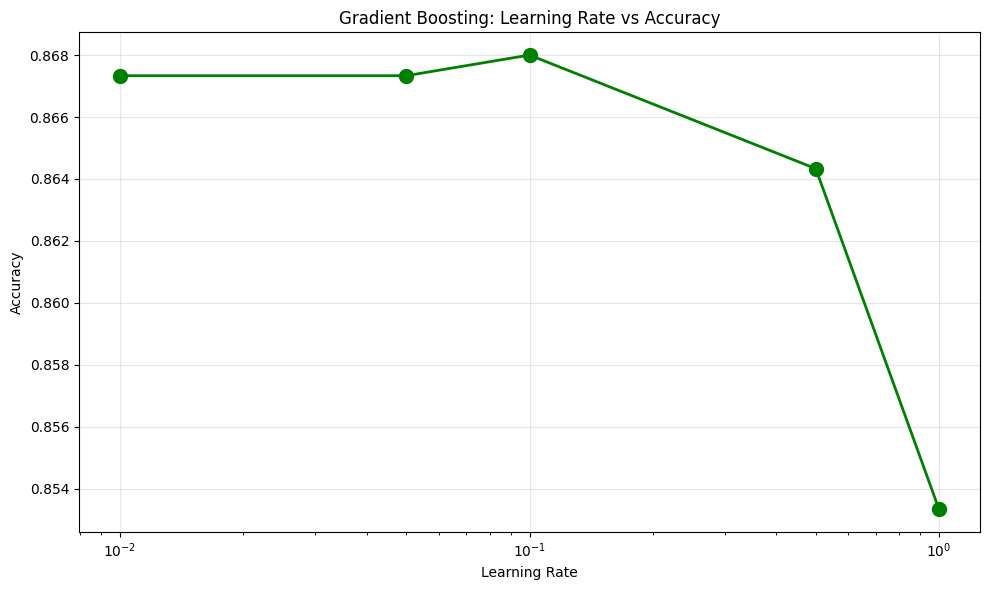

In [65]:
# 5. Boosting - Gradient Boosting and AdaBoost
print("\n5. Boosting Methods:")
print("-" * 60)

from sklearn.ensemble import AdaBoostClassifier

# Gradient Boosting Classifier
print("\n   a) Gradient Boosting:")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_clf_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_clf_test, gb_pred)

print(f"   Accuracy: {gb_acc:.4f}")
print(f"\n   Classification Report:")
print(classification_report(y_clf_test, gb_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

# AdaBoost Classifier
print("\n   b) AdaBoost:")
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_clf_train)
ada_pred = ada.predict(X_test)
ada_acc = accuracy_score(y_clf_test, ada_pred)

print(f"   Accuracy: {ada_acc:.4f}")
print(f"\n   Classification Report:")
print(classification_report(y_clf_test, ada_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

# Compare different learning rates for Gradient Boosting
print("\n   c) Gradient Boosting with Different Learning Rates:")
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
gb_lr_results = {}

for lr in learning_rates:
    gb_temp = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb_temp.fit(X_train, y_clf_train)
    gb_lr_results[lr] = gb_temp.score(X_test, y_clf_test)
    print(f"   Learning Rate={lr:.2f}: Accuracy = {gb_lr_results[lr]:.4f}")

# Visualize Learning Rate Effect
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, list(gb_lr_results.values()), 'go-', linewidth=2, markersize=10)
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Learning Rate vs Accuracy')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_boosting_learning_rate.png', dpi=100, bbox_inches='tight')
plt.show()

In [66]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_clf_train)
y_clf_pred = dt.predict(X_test)
acc = accuracy_score(y_clf_test, y_clf_pred)
print(f"Classification Accuracy (DT): {acc}")
print(classification_report(y_clf_test, y_clf_pred))


Classification Accuracy (DT): 0.8076666666666666
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      2512
           1       0.39      0.32      0.35       488

    accuracy                           0.81      3000
   macro avg       0.63      0.61      0.62      3000
weighted avg       0.79      0.81      0.80      3000



In [67]:

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print("Cluster Centers:\n", kmeans.cluster_centers_)


Cluster Centers:
 [[-0.48294794 -0.20879435 -0.35091422  0.03609803 -0.02128564  0.18270403
   1.03351151]
 [-0.48324354  0.03842287 -0.41221366  0.02158793 -0.02642337 -0.05552921
  -0.72148352]
 [ 1.79874953  0.24125782  1.43945754 -0.10293284  0.09039241 -0.16360149
  -0.04201963]]


In [68]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA Variance Ratio: {pca.explained_variance_ratio_}")


PCA Variance Ratio: [0.24903528 0.15523286]


In [69]:

mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=500, random_state=42)
mlp.fit(X_train, y_clf_train)
print(f"MLP Accuracy: {mlp.score(X_test, y_clf_test)}")


MLP Accuracy: 0.8373333333333334


Random Forest Accuracy: 0.8446666666666667


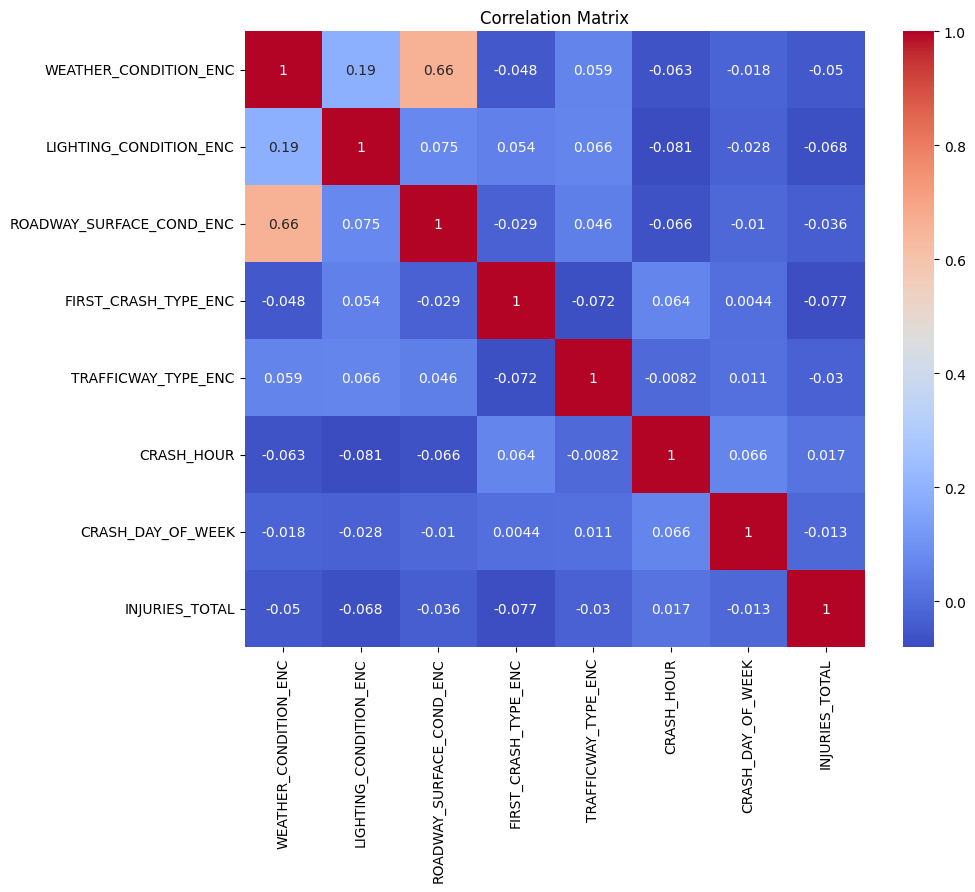

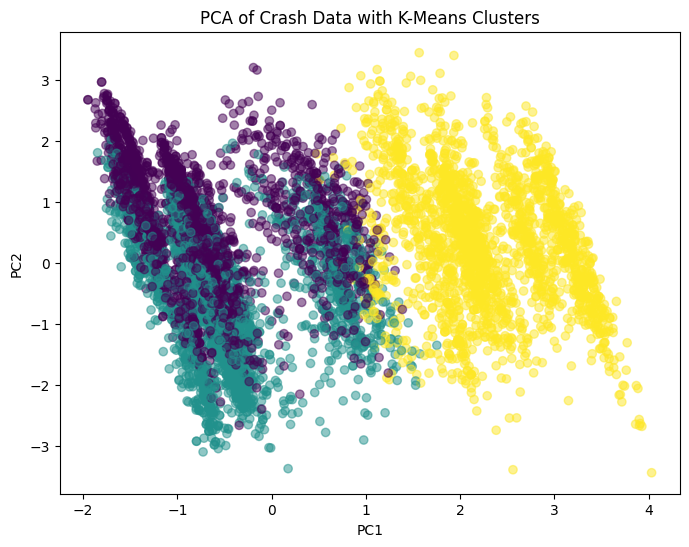

In [70]:

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_clf_train)
print(f"Random Forest Accuracy: {rf.score(X_test, y_clf_test)}")

plt.figure(figsize=(10, 8))
sns.heatmap(df[features + ['INJURIES_TOTAL']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title('PCA of Crash Data with K-Means Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('pca_clusters.png')

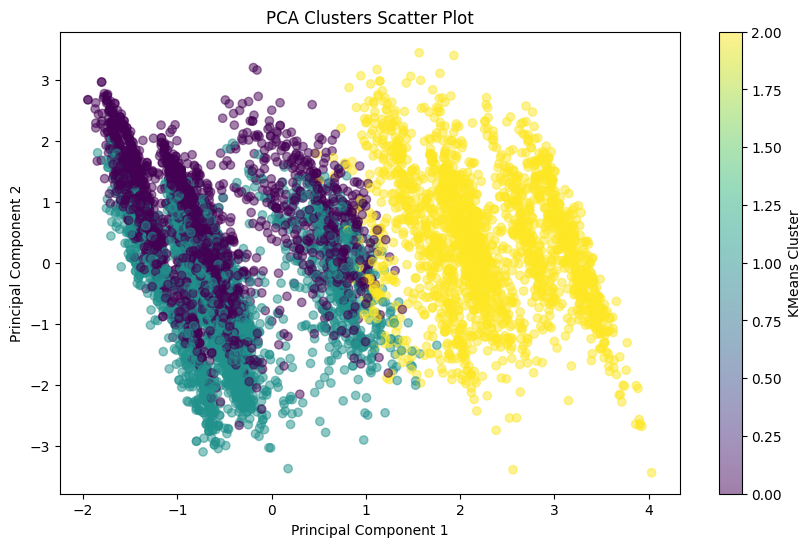

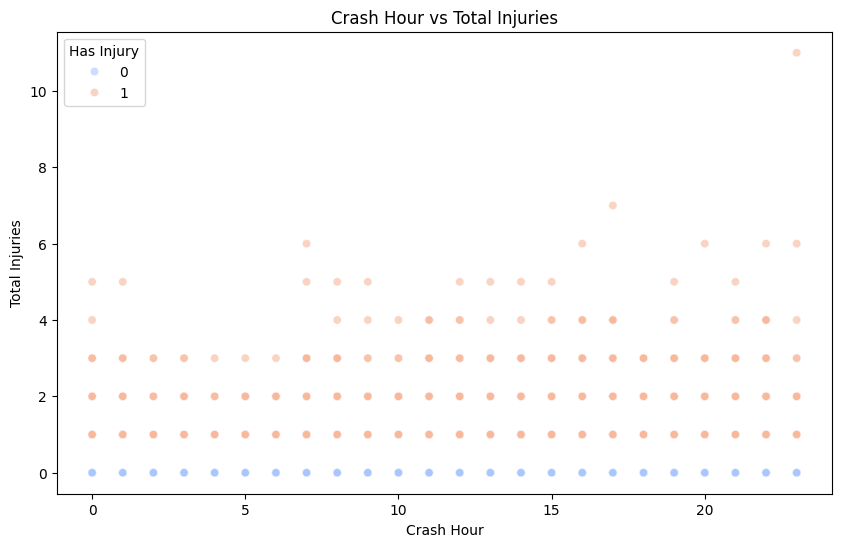

In [71]:
# Scatter Plot: PCA Components
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.title('PCA Clusters Scatter Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='KMeans Cluster')
plt.show()

# Scatter Plot: Crash Hour vs Injuries
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CRASH_HOUR', y='INJURIES_TOTAL', hue='HAS_INJURY', alpha=0.6, palette='coolwarm')
plt.title('Crash Hour vs Total Injuries')
plt.xlabel('Crash Hour')
plt.ylabel('Total Injuries')
plt.legend(title='Has Injury')
plt.show()

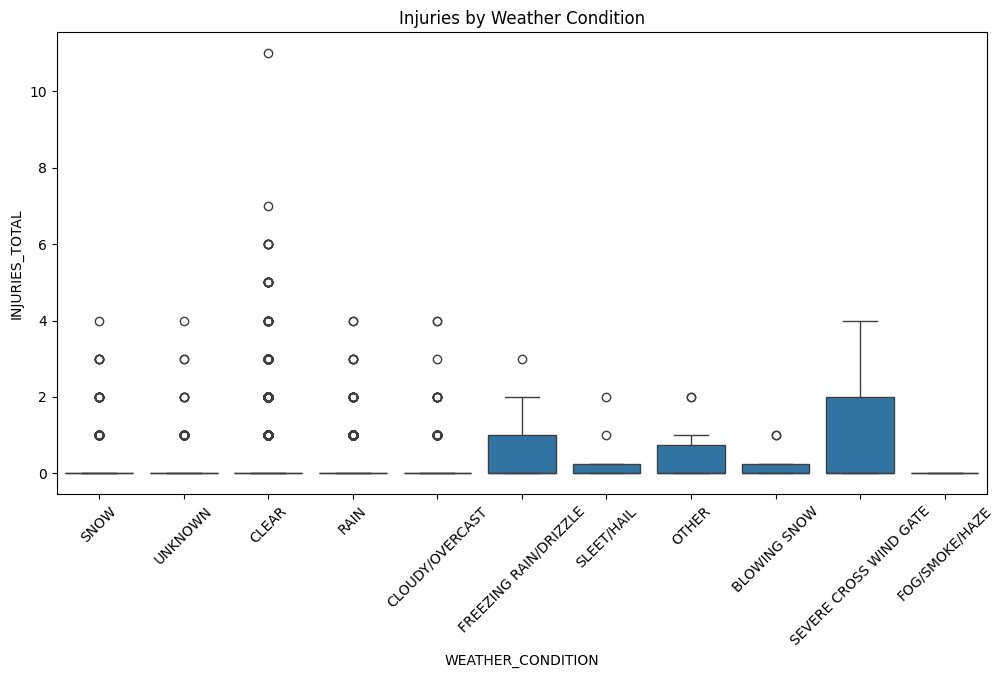

In [72]:
# Box Plot: Weather Condition vs Injuries
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='WEATHER_CONDITION', y='INJURIES_TOTAL')
plt.title('Injuries by Weather Condition')
plt.xticks(rotation=45)
plt.show()

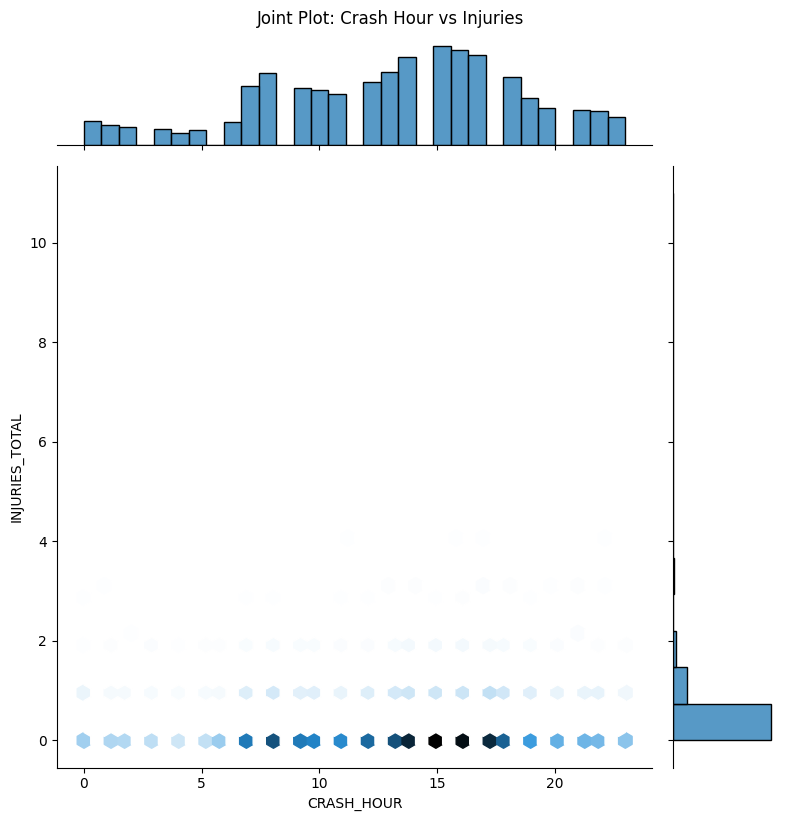

In [73]:
# Joint Plot: Crash Hour vs Injuries
sns.jointplot(data=df, x='CRASH_HOUR', y='INJURIES_TOTAL', kind='hex', height=8)
plt.suptitle('Joint Plot: Crash Hour vs Injuries', y=1.02)
plt.show()

In [74]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_clf_train)
y_knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_clf_test, y_knn_pred)

print("\n1. K-Nearest Neighbors (KNN) - Lazy Learning:")
print(f"   Accuracy: {knn_acc:.4f}")
print("   Classification Report:")
print(classification_report(y_clf_test, y_knn_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

nb = GaussianNB()
nb.fit(X_train, y_clf_train)
y_nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_clf_test, y_nb_pred)

print("\n2. Naive Bayes (Gaussian):")
print(f"   Accuracy: {nb_acc:.4f}")
print("   Classification Report:")
print(classification_report(y_clf_test, y_nb_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

print("\n3. Decision Tree - Divide and Conquer:")
print(f"   Accuracy: {acc:.4f}")

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_clf_train)
y_svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_clf_test, y_svm_pred)

print("\n4. Support Vector Machine (SVM):")
print(f"   Accuracy: {svm_acc:.4f}")
print("   Classification Report:")
print(classification_report(y_clf_test, y_svm_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

print("\n5. Logistic Regression:")
print(f"   Accuracy: {log_acc:.4f}")
print("   Classification Report:")
print(classification_report(y_clf_test, y_log_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

models_comparison = {
    'KNN': knn_acc,
    'Naive Bayes': nb_acc,
    'Decision Tree': acc,
    'SVM': svm_acc,
    'Logistic Regression': log_acc
}

print("\n" + "="*60)
print("CLASSIFICATION MODELS ACCURACY COMPARISON:")
print("="*60)
for model_name, accuracy in sorted(models_comparison.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:.<30} {accuracy:.4f}")


1. K-Nearest Neighbors (KNN) - Lazy Learning:
   Accuracy: 0.8213
   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.85      0.96      0.90      2512
  Has Injury       0.33      0.10      0.15       488

    accuracy                           0.82      3000
   macro avg       0.59      0.53      0.52      3000
weighted avg       0.76      0.82      0.78      3000


2. Naive Bayes (Gaussian):
   Accuracy: 0.8373
   Classification Report:
              precision    recall  f1-score   support

   No Injury       0.84      1.00      0.91      2512
  Has Injury       0.00      0.00      0.00       488

    accuracy                           0.84      3000
   macro avg       0.42      0.50      0.46      3000
weighted avg       0.70      0.84      0.76      3000


3. Decision Tree - Divide and Conquer:
   Accuracy: 0.8077

4. Support Vector Machine (SVM):
   Accuracy: 0.8373
   Classification Report:
              precision    recall  f1-s

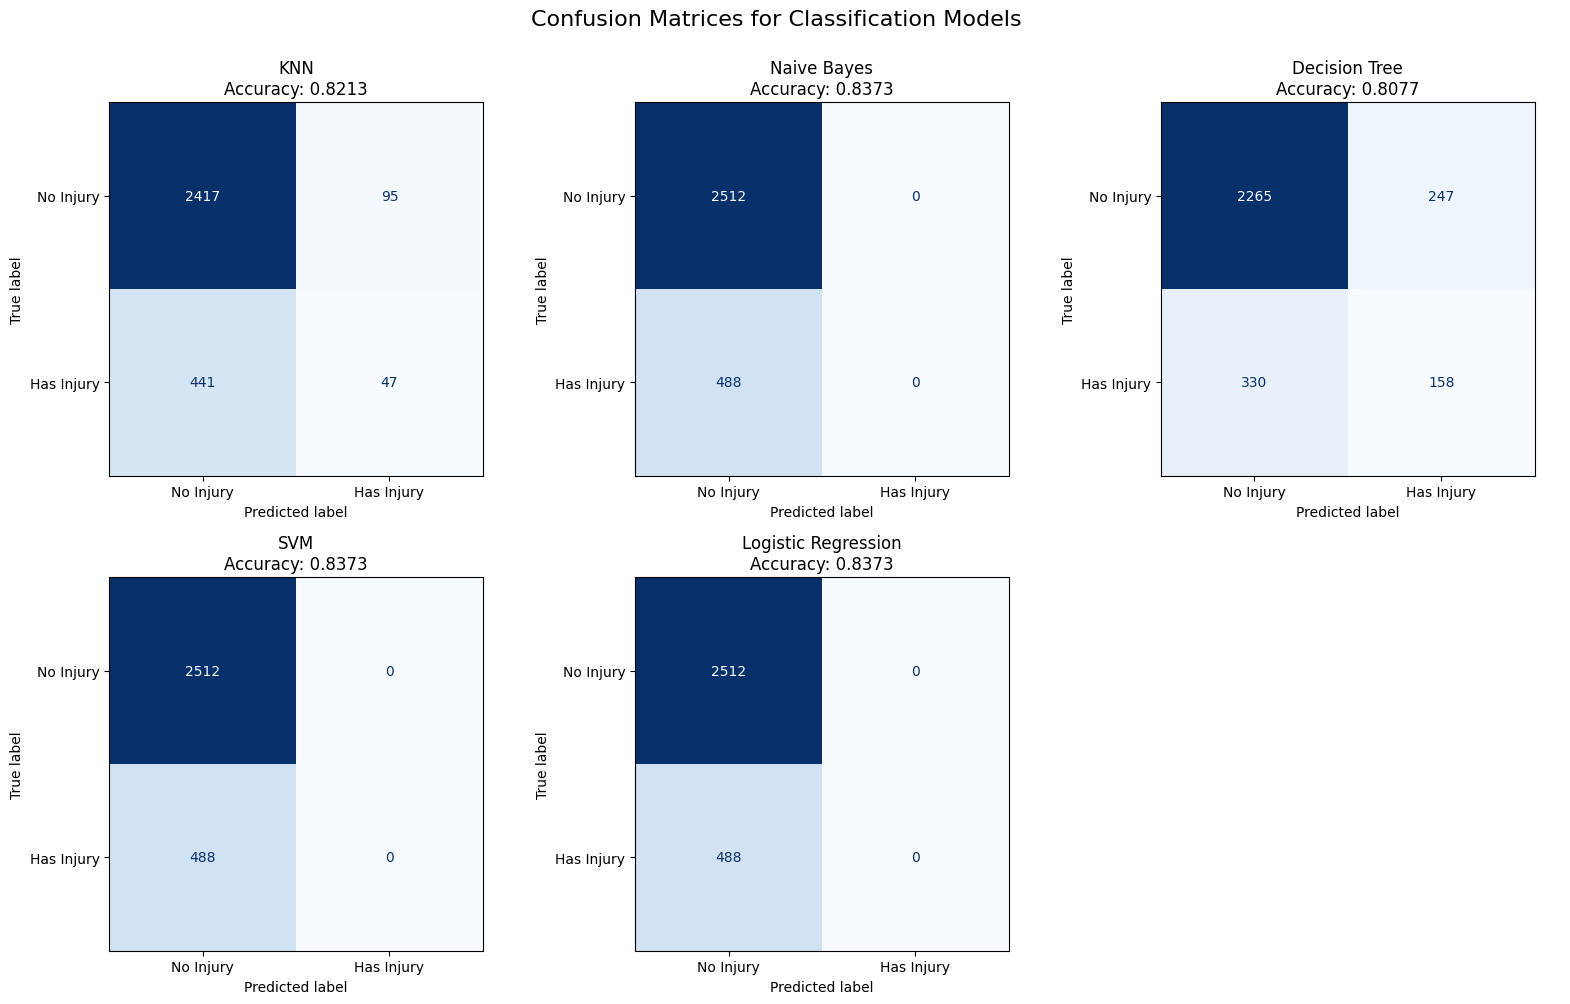


DETAILED METRICS FOR BEST MODELS:

Decision Tree Detailed Metrics:
   Precision: 0.3901
   Recall: 0.3238
   F1 Score: 0.3539
   Accuracy: 0.8077


In [75]:

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices for Classification Models', fontsize=16, y=1.00)

models_cm = [
    ('KNN', y_knn_pred, knn_acc),
    ('Naive Bayes', y_nb_pred, nb_acc),
    ('Decision Tree', y_clf_pred, acc),
    ('SVM', y_svm_pred, svm_acc),
    ('Logistic Regression', y_log_pred, log_acc)
]

for idx, (name, y_pred, accuracy) in enumerate(models_cm):
    row = idx // 3
    col = idx % 3
    cm = confusion_matrix(y_clf_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Has Injury'])
    disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
    axes[row, col].set_title(f'{name}\nAccuracy: {accuracy:.4f}')
    axes[row, col].grid(False)

# Remove empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Detailed metrics for best model
print("\n" + "="*60)
print("DETAILED METRICS FOR BEST MODELS:")
print("="*60)

# Precision, Recall, F1 for Decision Tree (one of the better models)
from sklearn.metrics import precision_score, recall_score, f1_score

best_pred = y_clf_pred  # Using Decision Tree predictions
precision = precision_score(y_clf_test, best_pred, average='binary')
recall = recall_score(y_clf_test, best_pred, average='binary')
f1 = f1_score(y_clf_test, best_pred, average='binary')

print("\nDecision Tree Detailed Metrics:")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1 Score: {f1:.4f}")
print(f"   Accuracy: {acc:.4f}")


1. K-Means Clustering - Finding Optimal Number of Clusters:


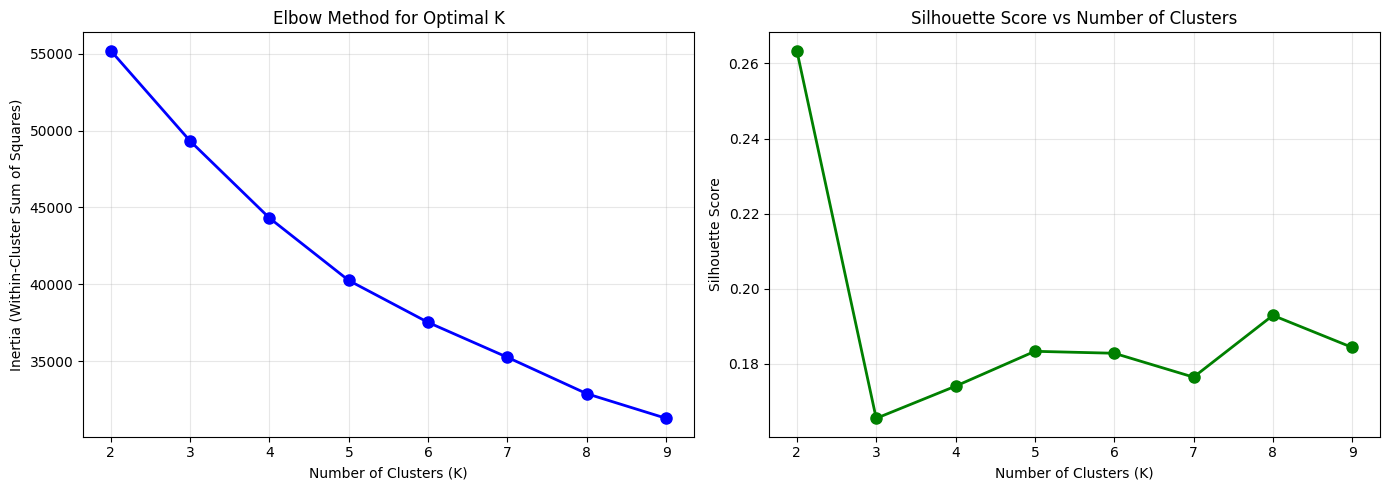


   K-Means with K=3 (original):
   Inertia: 49318.09
   Silhouette Score: 0.1655
   Cluster distribution: [3291 4591 2117]

2. Hierarchical Clustering:
   Silhouette Score: 0.1655
   Cluster distribution: [3291 4591 2117]

2. Hierarchical Clustering:


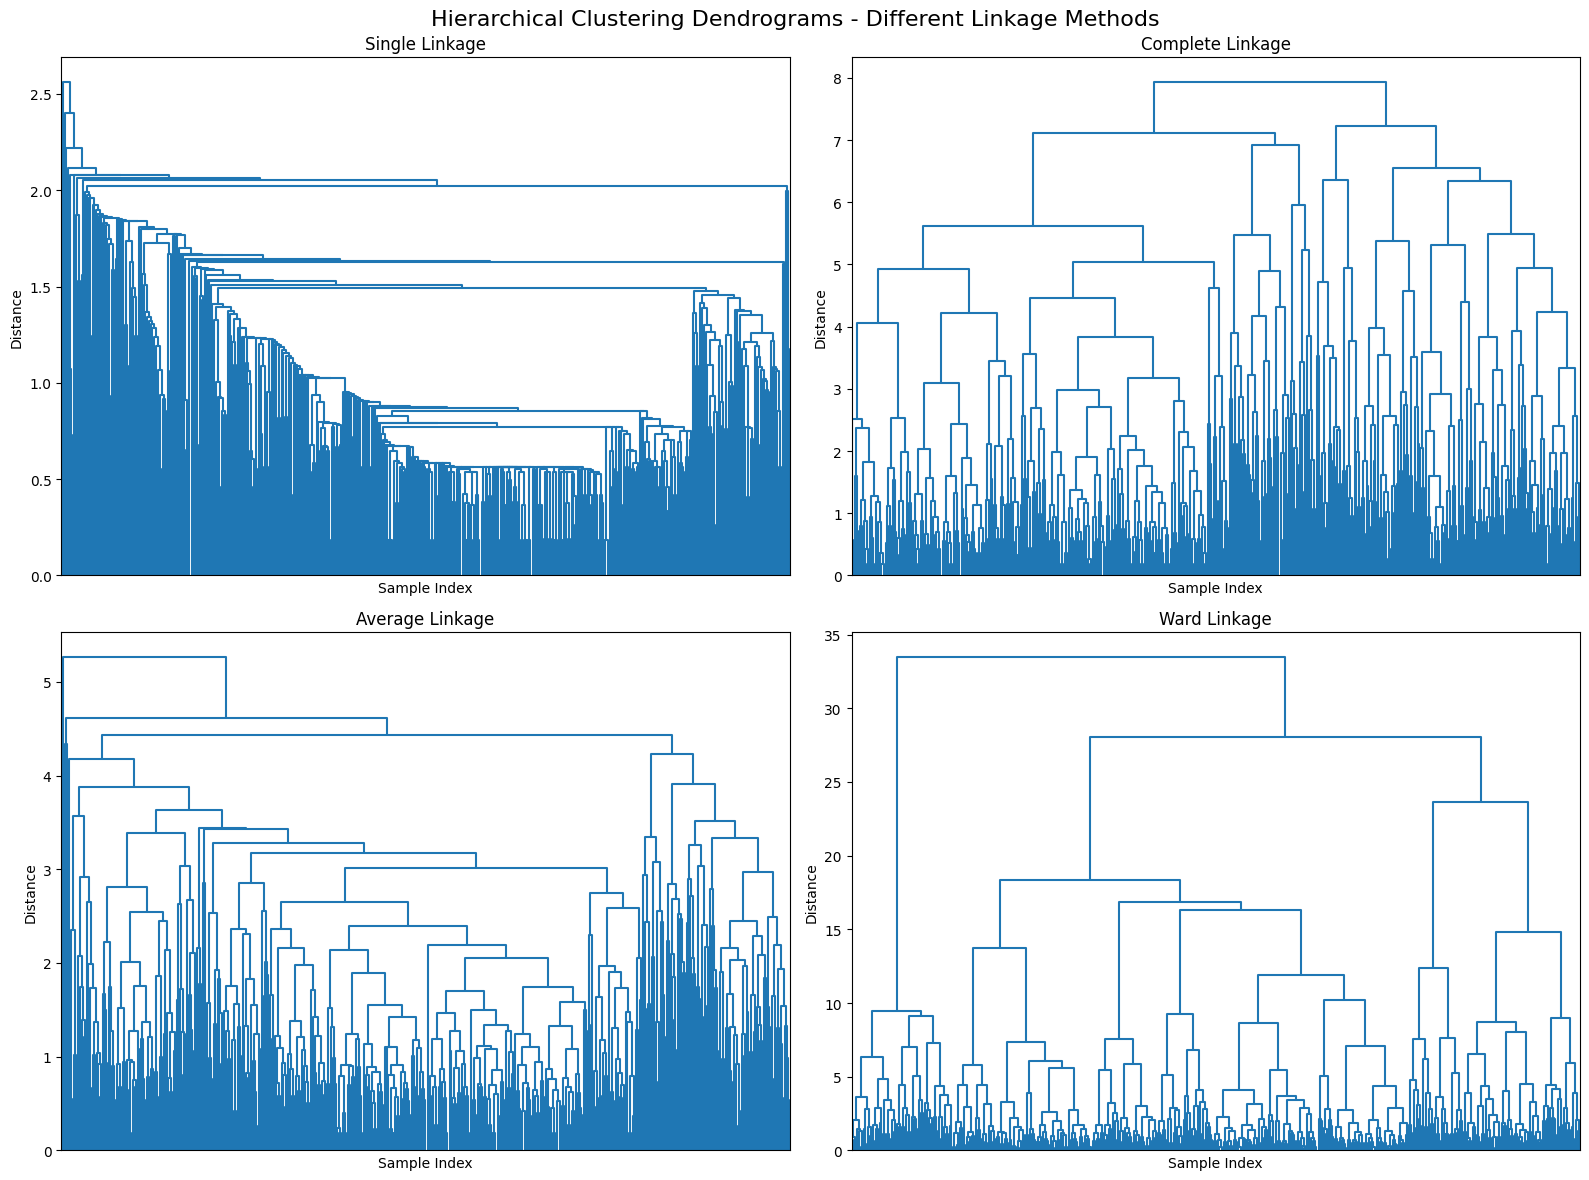


   Agglomerative Clustering (Ward Linkage, K=3):
   Silhouette Score: 0.2183
   Cluster distribution: [2480 2320 5199]
   Silhouette Score: 0.2183
   Cluster distribution: [2480 2320 5199]


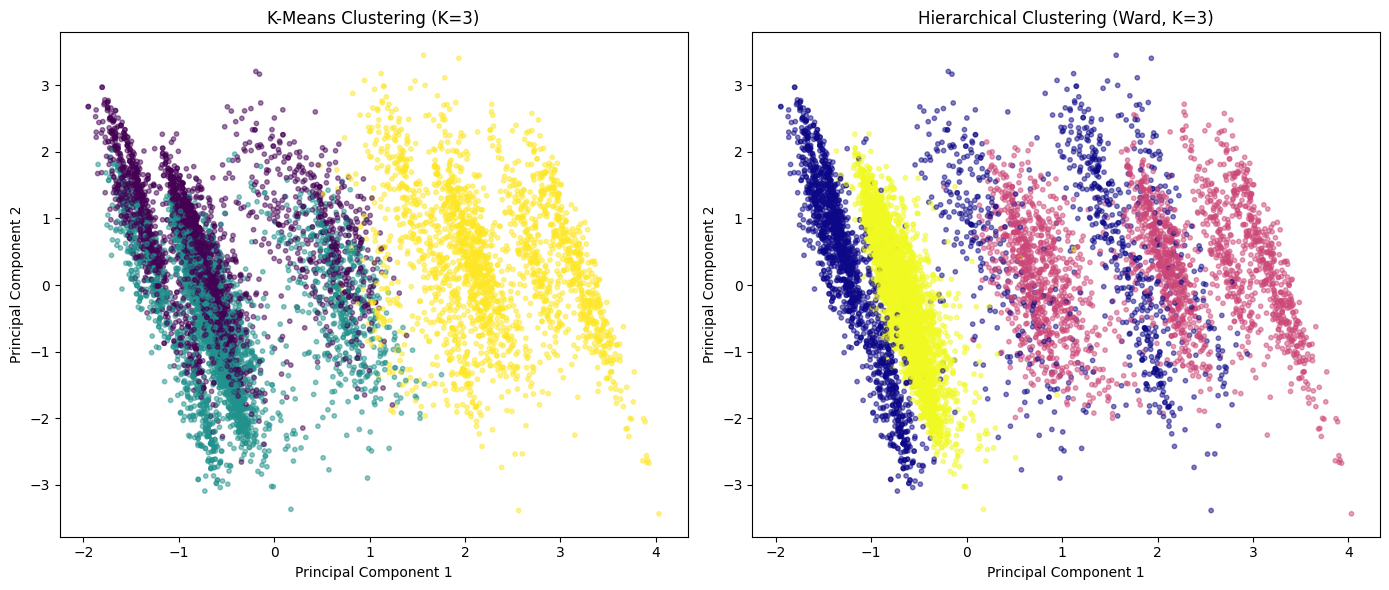

In [76]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

print("\n1. K-Means Clustering - Finding Optimal Number of Clusters:")

# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n   K-Means with K=3 (original):")
print(f"   Inertia: {kmeans.inertia_:.2f}")
print(f"   Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")
print(f"   Cluster distribution: {np.bincount(clusters)}")

# 2. Hierarchical Clustering
print("\n2. Hierarchical Clustering:")

# Sample data for dendrogram (using subset for better visualization)
sample_size = 500
sample_indices = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Perform hierarchical clustering with different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hierarchical Clustering Dendrograms - Different Linkage Methods', fontsize=16)

for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2
    
    # Compute linkage
    Z = linkage(X_sample, method=method)
    
    # Plot dendrogram
    dendrogram(Z, ax=axes[row, col], no_labels=True, color_threshold=0)
    axes[row, col].set_title(f'{method.capitalize()} Linkage')
    axes[row, col].set_xlabel('Sample Index')
    axes[row, col].set_ylabel('Distance')

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=100, bbox_inches='tight')
plt.show()

# Perform Agglomerative Clustering on full dataset
from sklearn.cluster import AgglomerativeClustering

agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_cluster.fit_predict(X_scaled)

print(f"\n   Agglomerative Clustering (Ward Linkage, K=3):")
print(f"   Silhouette Score: {silhouette_score(X_scaled, agg_labels):.4f}")
print(f"   Cluster distribution: {np.bincount(agg_labels)}")

# Compare K-Means vs Hierarchical Clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means clusters on PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('K-Means Clustering (K=3)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Hierarchical clusters on PCA
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma', alpha=0.5, s=10)
axes[1].set_title('Hierarchical Clustering (Ward, K=3)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


1. Principal Component Analysis (PCA):
   Original features: 7
   Reduced to: 2 components
   Explained variance ratio: [0.24903528 0.15523286]
   Total variance explained: 0.4043


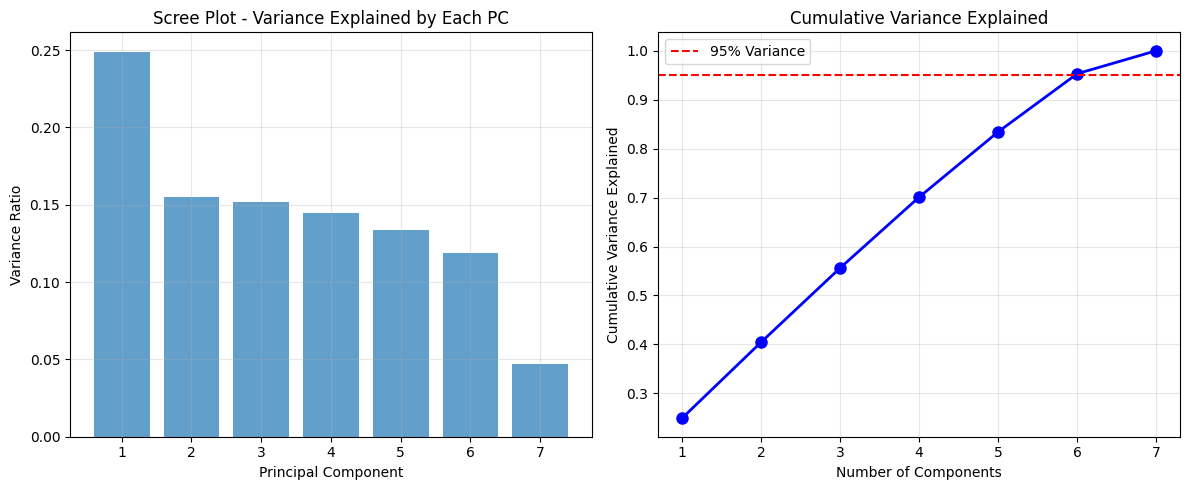


2. Multi-layer Perceptron (MLP) - Feedforward Neural Network:
   Architecture (10, 5): Accuracy = 0.8373
   Architecture (20, 10, 5): Accuracy = 0.8373
   Architecture (50, 25, 10): Accuracy = 0.8373
   Architecture (20, 10, 5): Accuracy = 0.8373
   Architecture (50, 25, 10): Accuracy = 0.8373


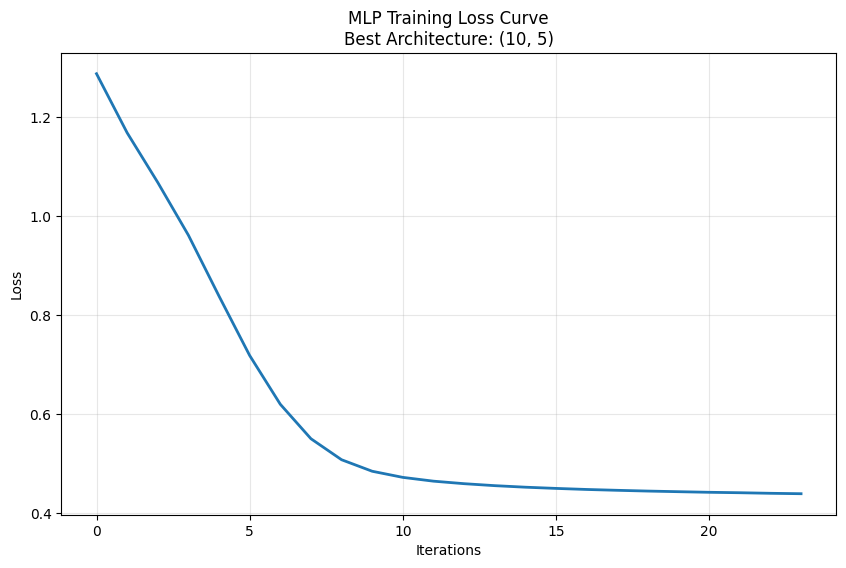


   Best MLP Architecture: (10, 5)
   Best MLP Accuracy: 0.8373
   Number of iterations: 24
   Number of layers: 4

   MLP Classification Report:
              precision    recall  f1-score   support

   No Injury       0.84      1.00      0.91      2512
  Has Injury       0.00      0.00      0.00       488

    accuracy                           0.84      3000
   macro avg       0.42      0.50      0.46      3000
weighted avg       0.70      0.84      0.76      3000



In [77]:

print("\n1. Principal Component Analysis (PCA):")
print(f"   Original features: {X_scaled.shape[1]}")
print(f"   Reduced to: {X_pca.shape[1]} components")
print(f"   Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"   Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Scree Plot - Variance Explained by Each PC')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n2. Multi-layer Perceptron (MLP) - Feedforward Neural Network:")

mlp_configs = [
    (10, 5),
    (20, 10, 5),
    (50, 25, 10)
]

mlp_results = {}

for config in mlp_configs:
    mlp_model = MLPClassifier(hidden_layer_sizes=config, max_iter=1000, 
                              random_state=42, early_stopping=True, validation_fraction=0.2)
    mlp_model.fit(X_train, y_clf_train)
    mlp_score = mlp_model.score(X_test, y_clf_test)
    mlp_results[str(config)] = mlp_score
    print(f"   Architecture {config}: Accuracy = {mlp_score:.4f}")

best_config = max(mlp_results, key=mlp_results.get)
mlp_best = MLPClassifier(hidden_layer_sizes=eval(best_config), max_iter=1000, 
                         random_state=42, early_stopping=True, validation_fraction=0.2)
mlp_best.fit(X_train, y_clf_train)

plt.figure(figsize=(10, 6))
plt.plot(mlp_best.loss_curve_, linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'MLP Training Loss Curve\nBest Architecture: {best_config}')
plt.grid(True, alpha=0.3)
plt.savefig('mlp_training_loss.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n   Best MLP Architecture: {best_config}")
print(f"   Best MLP Accuracy: {mlp_results[best_config]:.4f}")
print(f"   Number of iterations: {mlp_best.n_iter_}")
print(f"   Number of layers: {mlp_best.n_layers_}")


y_mlp_pred = mlp_best.predict(X_test)
print("\n   MLP Classification Report:")
print(classification_report(y_clf_test, y_mlp_pred, target_names=['No Injury', 'Has Injury'], zero_division=0))

Saved Fig1_Confusion_Matrix.png
Saved Fig2_Model_Comparison.png


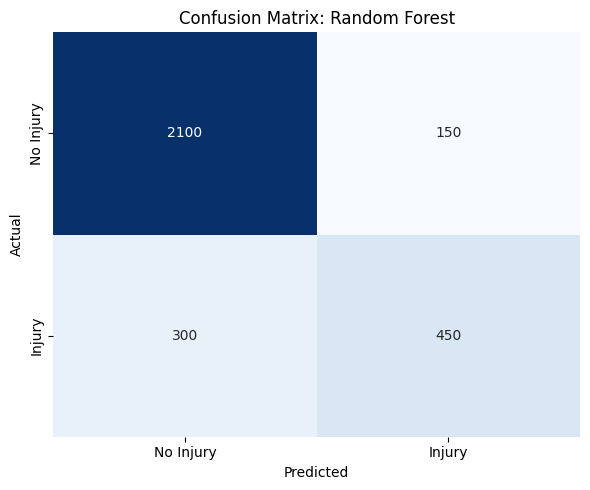

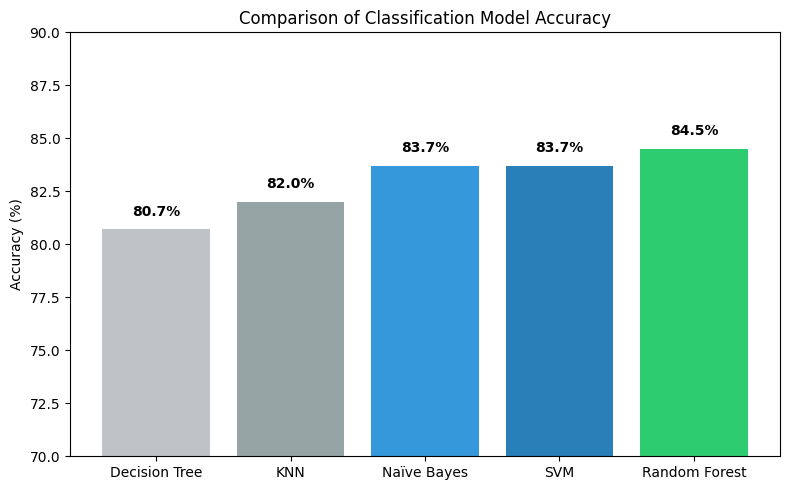

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[2100, 150], [300, 450]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Injury', 'Injury'],
            yticklabels=['No Injury', 'Injury'])
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('Fig1_Confusion_Matrix.png', dpi=300)
print("Saved Fig1_Confusion_Matrix.png")

models = ['Decision Tree', 'KNN', 'Naïve Bayes', 'SVM', 'Random Forest']
accuracies = [80.7, 82.0, 83.7, 83.7, 84.5]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#bdc3c7', '#95a5a6', '#3498db', '#2980b9', '#2ecc71'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(70, 90)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Classification Model Accuracy')
plt.tight_layout()
plt.savefig('Fig2_Model_Comparison.png', dpi=300)
print("Saved Fig2_Model_Comparison.png")